# **PyTorch WorkFlow**

In [17]:
# Import Library
import torch
from torch import nn

import matplotlib.pyplot as plt

## **1. Data Preparing and Loading**
Data can be almost anything, such as:
* Excel spreadsheet
* Images of any kind
* Videos
* Audio
* DNA
* Text

Machine Learning is a game of two parts:
* Transform data into numerical representation
* Build a model to learn the pattern from that numerical representation

To showcase this, let's build some *known* data using the linear regression formula

We'll use a linear regression formula to make a straight line with *known* parameters

Note:
- X: Matrix or Tensor
- x: Vector

In [18]:
# Create known parameters
bias = 0.3
weight = 0.7

# Create X and y
start = 0
stop = 1
step = 0.02

X = torch.arange(start, stop, step).unsqueeze(dim=1)
y = bias + weight * X

print(X[:10])
print(y[:10])

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


### 1.1 Splitting data into training and test sets
* Generalization: The ability for a machine learning model to perform well on data it hasn't seen before

In [19]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [20]:
def plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=None
):
  """
  Plots training data, test data, and compare predictions
  """
  fig, ax = plt.subplots(figsize=(10,7))

  # Plot train data in blue
  ax.scatter(train_data, train_labels, c="b", s=4, labels="Training Data")
  # plot test data in green
  ax.scatter(test_data, test_labels, c="g", s=4, labels="Testing Data")

  if predictions is not None:
    ax.scatter(test_data, predictions, c="r", s=4, labels="Predictions")

  plt.legend(prop={"size": 14})
  plt.show()

In [21]:
def plot_predictions(
    train_data,
    train_labels,
    test_data,
    test_labels,
    predictions=None
):
    """
    Plot training data, test data, and model predictions.

    Parameters
    ----------
    train_data : array-like
        Input features for training data.
    train_labels : array-like
        Target values for training data.
    test_data : array-like
        Input features for test data.
    test_labels : array-like
        Target values for test data.
    predictions : array-like, optional
        Model predictions for test data.
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    ax.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
    ax.scatter(test_data, test_labels, c="g", s=4, label="Testing Data")

    if predictions is not None:
        ax.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    ax.legend(prop={"size": 14})
    plt.show()


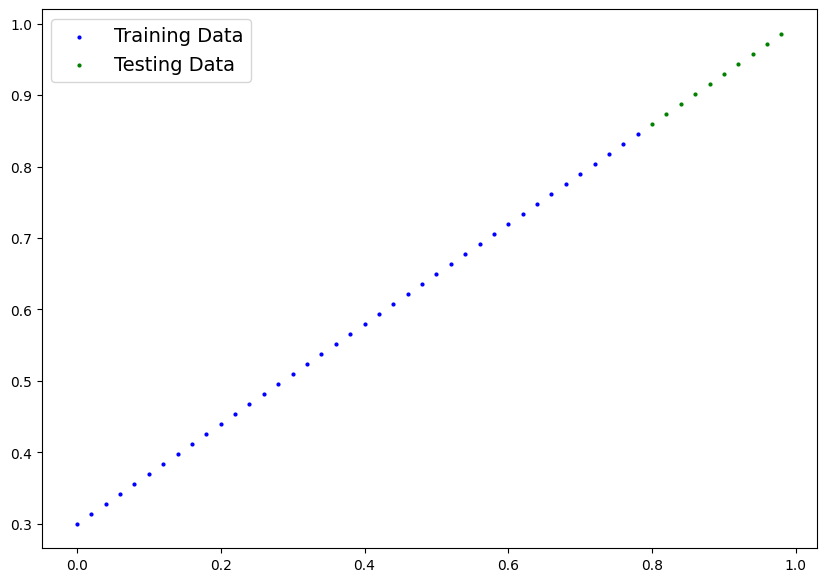

In [22]:
plot_predictions(X_train, y_train, X_test, y_test)

## **2. Build Model**
Building our first PyTorch model

Two main algorithms:
* [Gradient descent](https://www.youtube.com/watch?v=IHZwWFHWa-w)
* [Backpropagation](https://www.youtube.com/watch?v=Ilg3gGewQ5U)

In [23]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(
        torch.randn(
            1, # <- start with a random weights and try to adjust it into ideal weights
            requires_grad=True, # <- can this parameter be updated via gradient descent
            dtype=torch.float)
        )

    self.bias = nn.Parameter(
        torch.randn(
            1,
            requires_grad=True,
            dtype=torch.float)
        )

  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor):
    return self.weights * x + self.bias

### 2.2 PyTorch model building essentials

| Component | Description |
|---|---|
| `torch.nn` | Contains all building blocks for computational graphs (neural networks can be considered a computational graph) |
| `torch.nn.Parameter` | Defines what parameters the model should learn, often set automatically by `torch.nn` layers |
| `torch.nn.Module` | Base class for all neural network modules, requires overwriting `forward()` if subclassed |
| `torch.optim` | Contains optimizers in PyTorch that help with gradient descent |
| `def forward()` | Required method for all `nn.Module` subclasses, defines what happens in the forward computation |

See more via the [PyTorch cheatsheet](https://pytorch-cn.com/tutorials/beginner/ptcheat.html)

### 2.3 Checking the content of our PyTorch model
Now we've created a model

Let's see what inside our model using [`.parameters()`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.parameters)

In [24]:
LinearRegressionModel().weights, LinearRegressionModel().bias

(Parameter containing:
 tensor([-2.0302], requires_grad=True),
 Parameter containing:
 tensor([0.1355], requires_grad=True))

In [25]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [26]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### 2.4 Making predictions using [`torch.inference_mode()`](https://docs.pytorch.org/docs/stable/generated/torch.autograd.grad_mode.inference_mode.html)

See more [PyTorch inference mode on X](https://x.com/PyTorch/status/1437838231505096708?lang=en)

When we pass data through our model, it's going to run it through the [`forward()`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.forward) method

In [27]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [28]:
# Make predictions with the model
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [29]:
# We can also make it like this, however torch.inference_mode() is preferred
with torch.no_grad():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [30]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

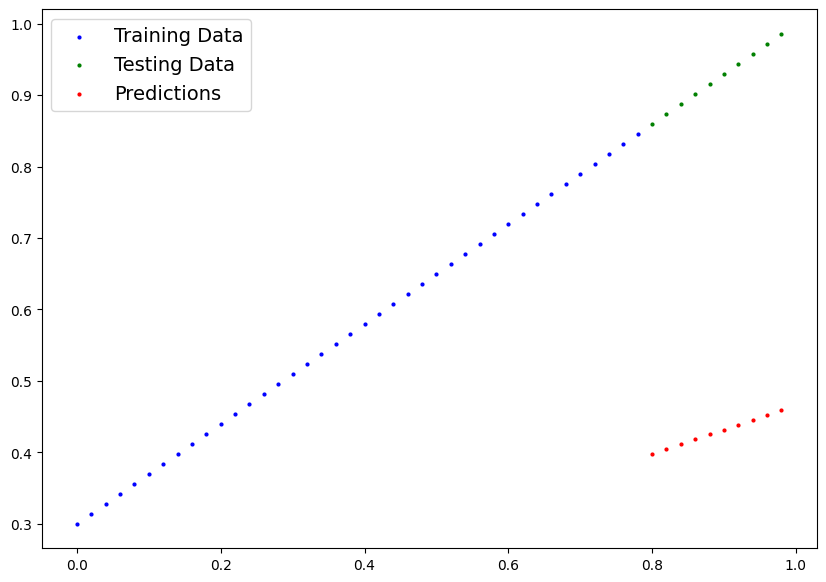

In [31]:
plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=y_preds)

## **3. Train Model**

The whole idea of training is for a model to move from some *unknown* parameters into *known* parameters

One way to measure how poor our predictions model are is to use **loss function**

* Note: loss function may also be called as cost function or criterion in different areas.

Things we need to train:
* **Loss function:** A function to measure how poor our predictive model are to the ideals output.
* **Optimizer:**  Takes into account the loss of a model and adjust it's parameters (e.g. weight and bias) to improve our loss function

Inside the optimizer, we often to set two hyperparameters:
* `params` - the model parameters you like to optimize, for example `params=model_0.parameters()`
* `lr` (learning rate) - the learning rate is hyperparameter that defines how small/big the optimizer changes the parameter with each step

In [32]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [33]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [34]:
# Set up a loss function
loss_fn = nn.L1Loss()

# Set up optimizer
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.01
)

* Learning rate (lr): defines how big/small the optimizer changes the parameter with each step

* The choice of loss function depends on the learning objective, while the optimizer determines how the model parameters are updated.

* For regression tasks, loss functions such as Mean Squared Error (MSELoss) or Mean Absolute Error (L1Loss) are commonly used. Optimizers like SGD or Adam can be applied, with Adam being more robust in practice.

* For binary classification tasks (e.g., cat vs dog classification), Binary Cross Entropy–based losses such as `BCEWithLogitsLoss` are commonly used.

### 3.1 PyTorch training loop

For the training loop, we'll build the following steps:

| Step | What does it do? | Code example |
|---|---|---|
| **1. Zero gradients** | The optimizer's gradients are set to zero (they are accumulated by default) so they can be recalculated for the current training step. | `optimizer.zero_grad()` |
| **2. Forward pass** | The model goes through all of the training data once, performing its `forward()` function calculations. | `model(x_train)` |
| **3. Calculate the loss** | The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are. | `loss = loss_fn(y_pred, y_train)` |
| **4. Backpropagation** | Computes the gradient of the loss with respect to every model parameter (`requires_grad=True`). This process is known as backpropagation. | `loss.backward()` |
| **5. Optimizer step** | Updates the model parameters using gradient descent based on the computed gradients. | `optimizer.step()` |

In [35]:
# Epoch: one loop through the data
epochs = 200

epoch_count = []
train_loss_value = []
test_loss_value = []

# Loop through the data
for epoch in range(epochs):
  ### Set the model to training mode
  model_0.train() # training mode in PyTorch sets all parameters that require gradients to require gradients

  # 1. Optimizer zero grad
  optimizer.zero_grad()
    
  # 2. Forward pass
  y_pred = model_0(X_train)

  # 3. Calculate the loss
  loss = loss_fn(y_pred, y_train) # loss(input, target)

  # 4. Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 5. Progress/step the optimizer (perform gradient descent)
  optimizer.step()

  ### Testing
  model_0.eval() # turn different settings in the model not needed for evaluating/testing (dropout off & batchnorm running stats)
  with torch.inference_mode(): # turns off gradient tracking, gradient: informasi tentang bagaimana parameter harus diubah agar loss mengecil
    # 1. Forward the test data
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  # Print out what's happening
  if epoch % 20 == 0 or epoch + 1 == epochs:
    epoch_count.append(epoch)
    train_loss_value.append(loss.item())
    test_loss_value.append(test_loss.item())

    print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test loss: {test_loss:.4f}")
    print(model_0.state_dict())

Epoch: 0 | Loss: 0.3129 | Test loss: 0.4811
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 20 | Loss: 0.0891 | Test loss: 0.2173
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 40 | Loss: 0.0454 | Test loss: 0.1136
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 60 | Loss: 0.0382 | Test loss: 0.0889
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 80 | Loss: 0.0313 | Test loss: 0.0723
OrderedDict({'weights': tensor([0.5459]), 'bias': tensor([0.3648])})
Epoch: 100 | Loss: 0.0245 | Test loss: 0.0565
OrderedDict({'weights': tensor([0.5800]), 'bias': tensor([0.3503])})
Epoch: 120 | Loss: 0.0176 | Test loss: 0.0406
OrderedDict({'weights': tensor([0.6141]), 'bias': tensor([0.3358])})
Epoch: 140 | Loss: 0.0107 | Test loss: 0.0241
OrderedDict({'weights': tensor([0.6485]), 'bias': tensor([0.3218])})
Epoch: 160 | Loss: 0.0039 | Test loss: 0.0082
OrderedDict({'weights': tensor([0.6826])

## **4. Making Predictions with Trained PyTorch Model (Inference)**

In [36]:
model_0.eval() # Dropout: off, BatchNorm: running mean/var
with torch.inference_mode():
  y_preds_new = model_0(X_test)

y_preds_new

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [37]:
for param in model_0.parameters():
  print(param.grad)

print("-"*35)

for name, param in model_0.named_parameters():
  print(name, param)

tensor([-0.3900])
tensor([-1.])
-----------------------------------
weights Parameter containing:
tensor([0.6990], requires_grad=True)
bias Parameter containing:
tensor([0.3093], requires_grad=True)


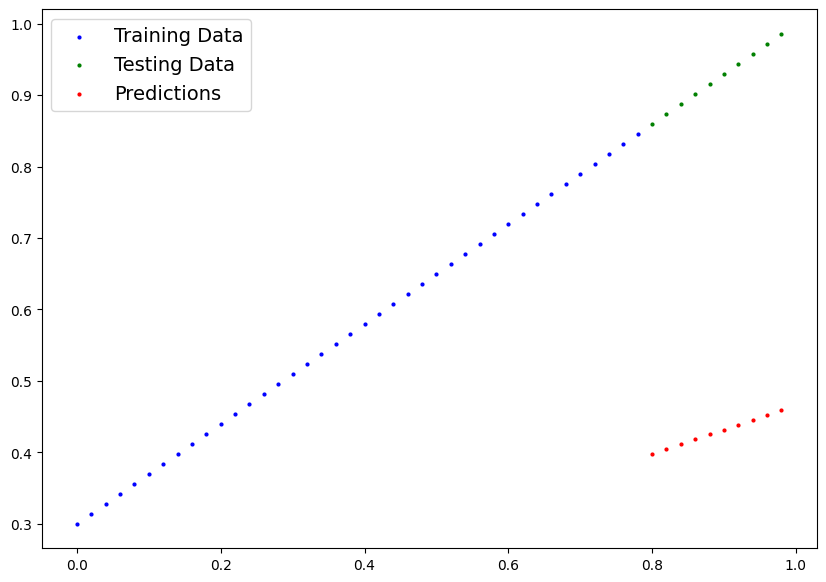

In [38]:
# Visualize the predictions
plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=y_preds
)

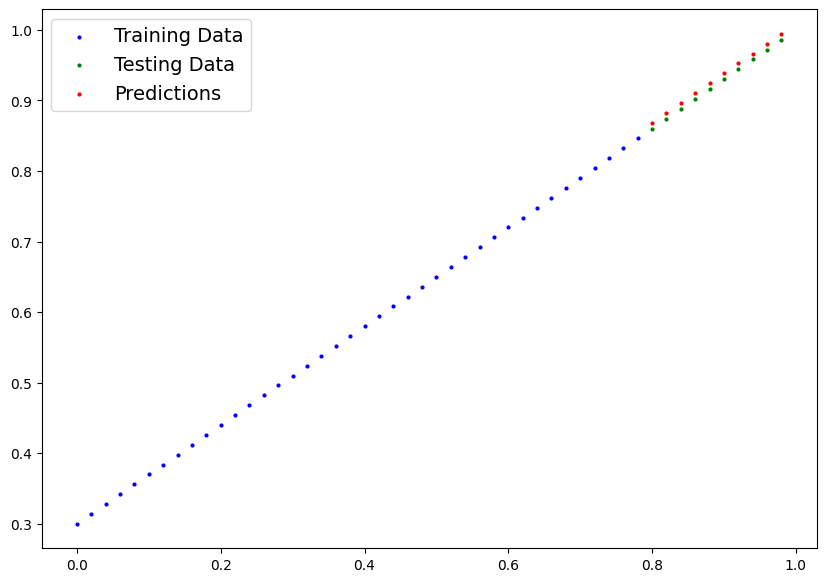

In [39]:
plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=y_preds_new
)

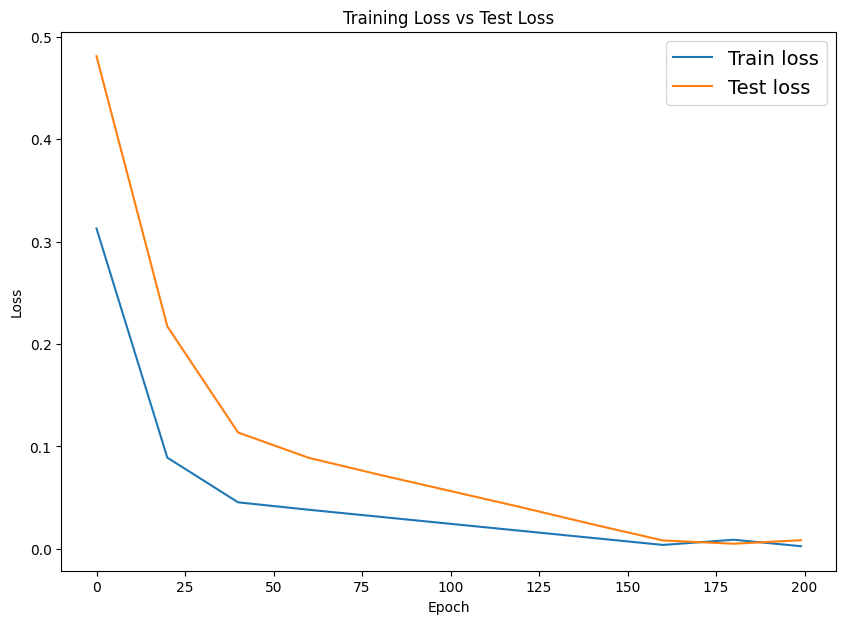

In [40]:
# Plot the training loss vs test loss
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(epoch_count, torch.tensor(train_loss_value).cpu().numpy(), label="Train loss")
ax.plot(epoch_count, test_loss_value, label="Test loss")

ax.set(
    xlabel="Epoch",
    ylabel="Loss",
    title="Training Loss vs Test Loss",
)

ax.legend(prop={"size": 14});

## **5. Saving and Loading a PyTorch Model**

* [`torch.save`](https://docs.pytorch.org/docs/stable/generated/torch.save.html): Saves a serialized object to disk using Python's pickle utility. Models, tensors and various other Python objects like dictionaries can be saved using torch.save.
* [`torch.load`](https://docs.pytorch.org/docs/stable/generated/torch.load.html): Uses pickle's unpickling features to deserialize and load pickled Python object files (like models, tensors or dictionaries) into memory. You can also set which device to load the object to (CPU, GPU etc).
* [`torch.nn.Module.load_state_dict`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.load_state_dict): Loads a model's parameter dictionary `model.state_dict()` using a saved `state_dict()` object.

In [41]:
from pathlib import Path

# 1. Create directory
PATH = Path("models")
PATH.mkdir(parents=True, exist_ok=True)

# 2. Create models save path
MODEL_NAME = "02_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)

Saving model to: models/02_pytorch_workflow_model_0.pth


In [42]:
!ls -l  models

total 4
-rw-r--r-- 1 root root 2117 Mar  8 20:07 02_pytorch_workflow_model_0.pth


Since we only saved the model's `state_dict()` which is a dictionary of learned parameters and not the entire model, we first have to load the `state_dict()` with `torch.load()` and then pass that `state_dict()` to a new instance of our model (which is a subclass of `nn.Module`).

In [43]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [44]:
# To load a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [45]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [46]:
# Make some predictions with our model
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [47]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [48]:
# Compare the predictions of the model with our loaded model
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## **6. Putting it All Together**

### 6.1 Data

In [49]:
# Import library
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.9.0+cu126'

In [50]:
# Set up device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [51]:
!nvidia-smi

Sun Mar  8 20:07:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [52]:
# Create parameters
weight = 0.5
bias = 0.2

# Create range values
start = 0
stop = 1
step = 0.025

# Create X and y (featured and labels)
X = torch.arange(start, stop, step).unsqueeze(dim=1)
y = weight * X + bias

In [53]:
# Split data
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

### 6.2 Building a PyTorch linear model

In [54]:
# Create linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
  # Instantiate the parameters by using nn.Linear
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(
        in_features=1,
        out_features=1
    )

  # Rewrite the forward method
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear(x)

In [55]:
# Create our object model
torch.manual_seed(42)

model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear.weight', tensor([[0.7645]])),
              ('linear.bias', tensor([0.8300]))]))

In [56]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [57]:
# Set the model device to GPU
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.3 Training model

For training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop

In [58]:
# Setup loss function
loss_fn = nn.L1Loss()

# Setup optimizer
optimizer = torch.optim.SGD(
    params=model_1.parameters(),
    lr=0.01
)

In [59]:
# Write a training loop
epochs = 200

# Setup device agnostic code
X_train, X_test, y_train, y_test = [
    v.to(device) for v in (X_train, X_test, y_train, y_test)
]

for epoch in range(epochs):
    # Set to training mode
    model_1.train()
    
    # 1. Optimizer zero grad
    optimizer.zero_grad()
    
    # 2. Forward pass
    y_pred = model_1(X_train)
    
    # 3. Calculate the loss
    loss = loss_fn(y_pred, y_train)
    
    # 4. Perform backpropagation
    loss.backward()
    
    # 5. Optimizer step
    optimizer.step()
    
    # Set to evaluation mode
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)
    
    # Print out the output
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.4f} | Test loss: {test_loss:.4f}")

Epoch: 0 | Train loss: 0.7325 | Test loss: 0.8513
Epoch: 10 | Train loss: 0.6175 | Test loss: 0.7170
Epoch: 20 | Train loss: 0.5025 | Test loss: 0.5826
Epoch: 30 | Train loss: 0.3875 | Test loss: 0.4482
Epoch: 40 | Train loss: 0.2725 | Test loss: 0.3138
Epoch: 50 | Train loss: 0.1574 | Test loss: 0.1794
Epoch: 60 | Train loss: 0.0424 | Test loss: 0.0450
Epoch: 70 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 80 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 90 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 100 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 110 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 120 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 130 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 140 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 150 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 160 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 170 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 180 | Train loss: 0.0045 | Test loss: 0.0127
Epoch: 190 | Train loss

In [60]:
model_1.state_dict()

OrderedDict([('linear.weight', tensor([[0.5076]], device='cuda:0')),
             ('linear.bias', tensor([0.1925], device='cuda:0'))])

In [61]:
weight, bias

(0.5, 0.2)

### 6.4 Making predictions

In [62]:
model_1.eval()
with torch.inference_mode():
  y_preds = model_1(X_test)

y_preds

tensor([[0.5986],
        [0.6113],
        [0.6240],
        [0.6367],
        [0.6494],
        [0.6621],
        [0.6747],
        [0.6874]], device='cuda:0')

In [63]:
len(X_train), len(X_test)

(32, 8)

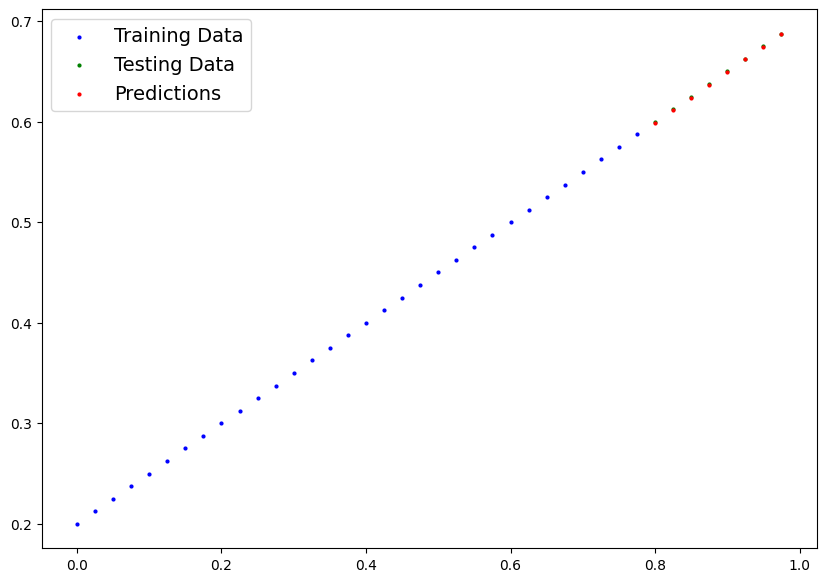

In [64]:
plot_predictions(X_train.cpu(), y_train.cpu(), X_test.cpu(), y_test.cpu(), y_preds.cpu())

### 6.5 Saving and load trained model

In [65]:
from pathlib import Path

# Create model's directory
PATH = Path("models")
PATH.mkdir(parents=True, exist_ok=True)

# Create model's save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = PATH / MODEL_NAME

torch.save(model_1.state_dict(), MODEL_SAVE_PATH)
print(f"Saving model to: {MODEL_SAVE_PATH}")

Saving model to: models/01_pytorch_workflow_model_1.pth


In [66]:
# Instantiate a fresh instance for our model
loaded_model_1 = LinearRegressionModelV2()

# Load model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put model to target device
loaded_model_1.to(device)

print(f"Using model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Using model:
LinearRegressionModelV2(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
cuda:0


In [67]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_pred = loaded_model_1(X_test)

y_preds == loaded_model_1_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')